Estación: Portal Norte, Cluster: 1
Estación: Toberin, Cluster: 1
Estación: U. Nacional, Cluster: 0
Estación: Calle 100, Cluster: 0
Estación: Portal Sur, Cluster: 2


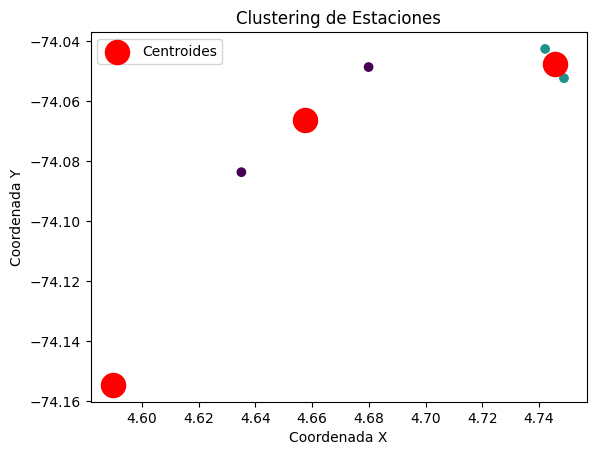

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Definir la clase Station
class Station:
    def __init__(self):
        self.stations = {}

    def add_station(self, name, coordinates):
        self.stations[name] = (name, coordinates)

    def distance(self, coord1, coord2):
        # Calcular la distancia euclidiana entre dos coordenadas
        return np.sqrt((coord1[0] - coord2[0]) ** 2 + (coord1[1] - coord2[1]) ** 2)

# Definir la clase Graph
class Graph:
    def __init__(self):
        self.vert_dict = {}
        self.num_vertices = 0

    def add_vertex(self, node, coordinates):
        self.num_vertices += 1
        self.vert_dict[node] = {'coordinates': coordinates, 'neighbors': {}}

    def add_edge(self, frm, to, cost=0):
        if frm not in self.vert_dict:
            self.add_vertex(frm, station.stations[frm][1])
        if to not in self.vert_dict:
            self.add_vertex(to, station.stations[to][1])

        # Añadir el vecino con su costo
        self.vert_dict[frm]['neighbors'][to] = cost
        self.vert_dict[to]['neighbors'][frm] = cost  # Asumiendo un grafo no dirigido

# Crear las estaciones y el grafo
station = Station()
graph = Graph()

# Añadir estaciones con sus coordenadas (ejemplos)
station.add_station('Portal Norte', (4.748825, -74.052272))
station.add_station('Toberin', (4.742177, -74.042500))
station.add_station('U. Nacional', (4.635070, -74.083648))
station.add_station('Calle 100', (4.679925, -74.048552))
station.add_station('Portal Sur', (4.589830, -74.154680))

# Crear conexiones ficticias (puedes agregar más conexiones reales)
graph.add_edge('Portal Norte', 'Toberin', station.distance(station.stations['Portal Norte'][1], station.stations['Toberin'][1]))
graph.add_edge('Toberin', 'U. Nacional', station.distance(station.stations['Toberin'][1], station.stations['U. Nacional'][1]))
graph.add_edge('U. Nacional', 'Calle 100', station.distance(station.stations['U. Nacional'][1], station.stations['Calle 100'][1]))
graph.add_edge('Calle 100', 'Portal Sur', station.distance(station.stations['Calle 100'][1], station.stations['Portal Sur'][1]))

# Ahora aplicar el algoritmo K-means para el modelo no supervisado

# Extraer las coordenadas de las estaciones
station_coordinates = np.array([coordinates for _, coordinates in station.stations.values()])

# Definir el número de clusters (grupos) que queremos formar
num_clusters = 3  # Puedes probar con diferentes valores para ver cuál se adapta mejor

# Crear el modelo K-means
kmeans = KMeans(n_clusters=num_clusters, random_state=0)

# Ajustar el modelo con las coordenadas de las estaciones
kmeans.fit(station_coordinates)

# Obtener las etiquetas de los clusters para cada estación
labels = kmeans.labels_

# Imprimir las etiquetas para cada estación
for idx, (station_name, _) in enumerate(station.stations.items()):
    print(f'Estación: {station_name}, Cluster: {labels[idx]}')

# Graficar los clusters
plt.scatter(station_coordinates[:, 0], station_coordinates[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='Centroides')
plt.title('Clustering de Estaciones')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.legend()
plt.show()


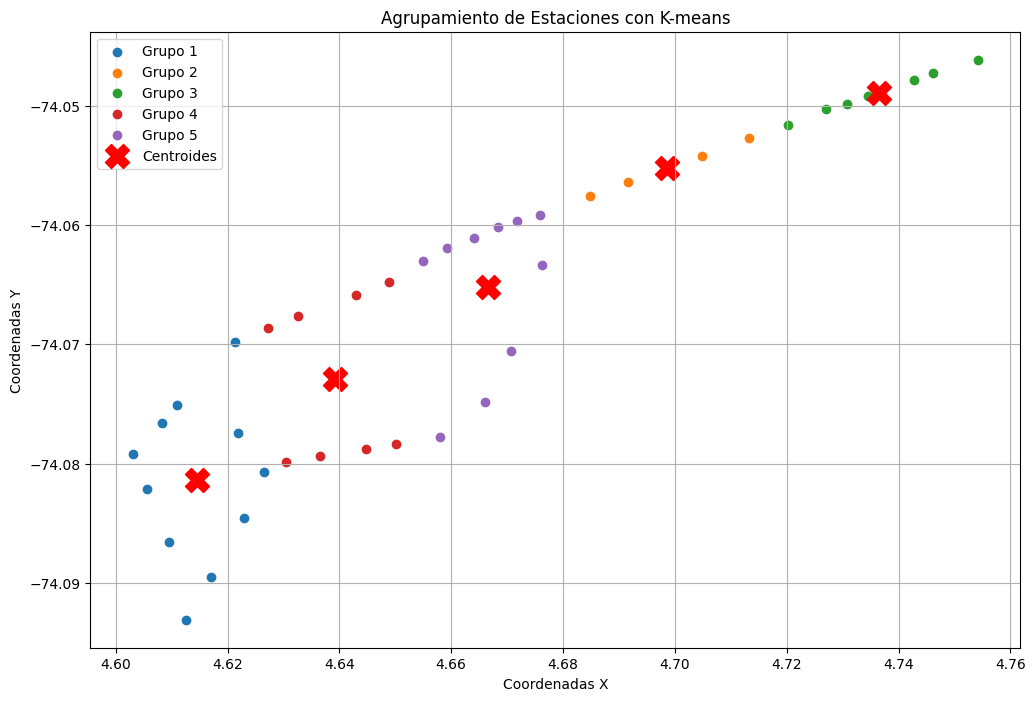

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

class Station:
    def __init__(self):
        self.stations = {}

    def add_station(self, name, coordinates):
        self.stations[name] = (name, coordinates)

    def distance(self, coord1, coord2):
        # Calcular la distancia euclidiana entre dos coordenadas
        return np.sqrt((coord1[0] - coord2[0]) ** 2 + (coord1[1] - coord2[1]) ** 2)

# Definir la clase Graph
class Graph:
    def __init__(self):
        self.vert_dict = {}
        self.num_vertices = 0

    def add_vertex(self, node, coordinates):
        self.num_vertices += 1
        self.vert_dict[node] = {'coordinates': coordinates, 'neighbors': {}}

    def add_edge(self, frm, to, cost=0):
        if frm not in self.vert_dict:
            self.add_vertex(frm, station.stations[frm][1])
        if to not in self.vert_dict:
            self.add_vertex(to, station.stations[to][1])

        self.vert_dict[frm]['neighbors'][to] = cost
        self.vert_dict[to]['neighbors'][frm] = cost

# Crear las estaciones y el grafo
station = Station()
graph = Graph()

# Añadir estaciones con sus coordenadas
stations_data = {
    'Portal Norte': (4.754228, -74.046161),
    'Toberin': (4.746185, -74.047279),
    'Calle 161': (4.742706, -74.047863),
    'Mazuren': (4.734499, -74.049242),
    'Calle 146': (4.730832, -74.049868),
    'Calle 142': (4.726947, -74.050305),
    'Alcala': (4.720287, -74.051641),
    'Prado': (4.713173, -74.052682),
    'Calle 127': (4.704787, -74.054230),
    'Pepe Sierra': (4.698795, -74.055251),
    'Calle 106': (4.691557, -74.056421),
    'Calle 100': (4.684800, -74.057570),
    'La Castellana': (4.676243, -74.063387),
    'NQS-Calle 75': (4.670653, -74.070593),
    'AV. Chile': (4.665962, -74.074819),
    'Simon Bolivar': (4.658008, -74.077797),
    'Movistar Arena': (4.650119, -74.078363),
    'Campin - U. Antonio Nariño': (4.644847, -74.078777),
    'AV. El Dorado': (4.630541, -74.079891),
    'CAD': (4.622983, -74.084559),
    'Paloquemao': (4.617084, -74.089525),
    'Ricaurte': (4.612523, -74.093075),
    'San Façon': (4.609549, -74.086540),
    'De La Sabana': (4.605659, -74.082138),
    'AV. Jiménez': (4.603037, -74.079164),
    'Virrey': (4.675857, -74.059144),
    'Calle 85': (4.671851, -74.059702),
    'Héroes': (4.668311, -74.060210),
    'Calle 76': (4.664031, -74.061083),
    'Calle 72': (4.659261, -74.061922),
    'Flores': (4.654878, -74.063021),
    'Calle 63': (4.648914, -74.064810),
    'Calle 57': (4.642917, -74.065879),
    'Calle 45': (4.632661, -74.067665),
    'AV. 39': (4.627184, -74.068643),
    'Calle 34': (4.621390, -74.069805),
    'Calle 22': (4.611033, -74.075079),
    'Calle 19': (4.608302, -74.076608),
    'Concejo de Bogotá': (4.626496, -74.080722),
    'Centro Memoria': (4.621915, -74.077436),
    'U. Nacional': (4.636493, -74.079328)
}

for name, coords in stations_data.items():
    station.add_station(name, coords)

# Crear conexiones ficticias (puedes agregar más conexiones reales)
graph.add_edge('Portal Norte', 'Toberin', station.distance(station.stations['Portal Norte'][1], station.stations['Toberin'][1]))
graph.add_edge('Toberin', 'Calle 161', station.distance(station.stations['Toberin'][1], station.stations['Calle 161'][1]))
graph.add_edge('Calle 161', 'Mazuren', station.distance(station.stations['Calle 161'][1], station.stations['Mazuren'][1]))
graph.add_edge('Mazuren', 'Calle 146', station.distance(station.stations['Mazuren'][1], station.stations['Calle 146'][1]))
graph.add_edge('Calle 146', 'Calle 142', station.distance(station.stations['Calle 146'][1], station.stations['Calle 142'][1]))
graph.add_edge('Calle 142', 'Alcala', station.distance(station.stations['Calle 142'][1], station.stations['Alcala'][1]))
graph.add_edge('Alcala', 'Prado', station.distance(station.stations['Alcala'][1], station.stations['Prado'][1]))
graph.add_edge('Prado', 'Calle 127', station.distance(station.stations['Prado'][1], station.stations['Calle 127'][1]))
graph.add_edge('Calle 127', 'Pepe Sierra', station.distance(station.stations['Calle 127'][1], station.stations['Pepe Sierra'][1]))
graph.add_edge('Pepe Sierra', 'Calle 106', station.distance(station.stations['Pepe Sierra'][1], station.stations['Calle 106'][1]))
graph.add_edge('Calle 106', 'Calle 100', station.distance(station.stations['Calle 106'][1], station.stations['Calle 100'][1]))
graph.add_edge('Calle 100', 'La Castellana', station.distance(station.stations['Calle 100'][1], station.stations['La Castellana'][1]))
graph.add_edge('La Castellana', 'NQS-Calle 75', station.distance(station.stations['La Castellana'][1], station.stations['NQS-Calle 75'][1]))
graph.add_edge('NQS-Calle 75', 'AV. Chile', station.distance(station.stations['NQS-Calle 75'][1], station.stations['AV. Chile'][1]))
graph.add_edge('AV. Chile', 'Simon Bolivar', station.distance(station.stations['AV. Chile'][1], station.stations['Simon Bolivar'][1]))
graph.add_edge('Simon Bolivar', 'Movistar Arena', station.distance(station.stations['Simon Bolivar'][1], station.stations['Movistar Arena'][1]))
graph.add_edge('Movistar Arena', 'Campin - U. Antonio Nariño', station.distance(station.stations['Movistar Arena'][1], station.stations['Campin - U. Antonio Nariño'][1]))
graph.add_edge('Campin - U. Antonio Nariño', 'AV. El Dorado', station.distance(station.stations['Campin - U. Antonio Nariño'][1], station.stations['AV. El Dorado'][1]))
graph.add_edge('AV. El Dorado', 'CAD', station.distance(station.stations['AV. El Dorado'][1], station.stations['CAD'][1]))
graph.add_edge('CAD', 'Paloquemao', station.distance(station.stations['CAD'][1], station.stations['Paloquemao'][1]))
graph.add_edge('Paloquemao', 'Ricaurte', station.distance(station.stations['Paloquemao'][1], station.stations['Ricaurte'][1]))
graph.add_edge('Ricaurte', 'San Façon', station.distance(station.stations['Ricaurte'][1], station.stations['San Façon'][1]))
graph.add_edge('San Façon', 'De La Sabana', station.distance(station.stations['San Façon'][1], station.stations['De La Sabana'][1]))
graph.add_edge('De La Sabana', 'AV. Jiménez', station.distance(station.stations['De La Sabana'][1], station.stations['AV. Jiménez'][1]))
graph.add_edge('AV. Jiménez', 'Virrey', station.distance(station.stations['AV. Jiménez'][1], station.stations['Virrey'][1]))
graph.add_edge('Virrey', 'Calle 85', station.distance(station.stations['Virrey'][1], station.stations['Calle 85'][1]))
graph.add_edge('Calle 85', 'Héroes', station.distance(station.stations['Calle 85'][1], station.stations['Héroes'][1]))
graph.add_edge('Héroes', 'Calle 76', station.distance(station.stations['Héroes'][1], station.stations['Calle 76'][1]))
graph.add_edge('Calle 76', 'Calle 72', station.distance(station.stations['Calle 76'][1], station.stations['Calle 72'][1]))
graph.add_edge('Calle 72', 'Flores', station.distance(station.stations['Calle 72'][1], station.stations['Flores'][1]))
graph.add_edge('Flores', 'Calle 63', station.distance(station.stations['Flores'][1], station.stations['Calle 63'][1]))
graph.add_edge('Calle 63', 'Calle 57', station.distance(station.stations['Calle 63'][1], station.stations['Calle 57'][1]))
graph.add_edge('Calle 57', 'Calle 45', station.distance(station.stations['Calle 57'][1], station.stations['Calle 45'][1]))
graph.add_edge('Calle 45', 'AV. 39', station.distance(station.stations['Calle 45'][1], station.stations['AV. 39'][1]))
graph.add_edge('AV. 39', 'Calle 34', station.distance(station.stations['AV. 39'][1], station.stations['Calle 34'][1]))
graph.add_edge('Calle 34', 'Calle 22', station.distance(station.stations['Calle 34'][1], station.stations['Calle 22'][1]))
graph.add_edge('Calle 22', 'Calle 19', station.distance(station.stations['Calle 22'][1], station.stations['Calle 19'][1]))
graph.add_edge('Calle 19', 'Concejo de Bogotá', station.distance(station.stations['Calle 19'][1], station.stations['Concejo de Bogotá'][1]))
graph.add_edge('Concejo de Bogotá', 'Centro Memoria', station.distance(station.stations['Concejo de Bogotá'][1], station.stations['Centro Memoria'][1]))
graph.add_edge('Centro Memoria', 'U. Nacional', station.distance(station.stations['Centro Memoria'][1], station.stations['U. Nacional'][1]))

# Obtener las coordenadas de las estaciones
coordinates = np.array([value[1] for value in station.stations.values()])

# Definir el número de grupos
n_clusters = 5

# Inicializar K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=0)

# Ajustar el modelo a las coordenadas
kmeans.fit(coordinates)

# Obtener etiquetas y centros de los grupos
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Visualizar los grupos
plt.figure(figsize=(12, 8))
for i in range(n_clusters):
    plt.scatter(coordinates[labels == i][:, 0], coordinates[labels == i][:, 1], label=f'Grupo {i + 1}')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroides')
plt.title('Agrupamiento de Estaciones con K-means')
plt.xlabel('Coordenadas X')
plt.ylabel('Coordenadas Y')
plt.legend()
plt.grid()
plt.show()
